## Part 1. POI Inspection and Preprocessing


In [ ]:
# Inspect the sampled POI files and write inventory/quality reports.
%run code/01_poi_inspect_inventory.py


In [ ]:
# Inspect POI category distributions and duplicate patterns.
%run code/02_poi_inspect_categories_duplicates.py


In [ ]:
# Clean sampled POI records into functional POI subclasses.
%run code/03_poi_clean_base.py


In [ ]:
# Patch the industrial POI subclass using company-category details.
%run code/04_poi_clean_industrial_patch.py


In [ ]:
# Aggregate POI subclasses to hexagonal grid cells.
%run code/05_poi_grid_score_counts.py


In [ ]:
# Apply frequency-density normalization to POI grid scores.
%run code/06_poi_grid_score_fd.py


## Part 2. Feature Extraction and Model Training


### Part 2.1. Data Preparation


#### 2020 GEE Feature Extraction


In [ ]:
# Submit the 2020 GEE feature export task.
# GThe project path in EE must be replaced with your own,
# and the corresponding folder path must first be created within GEE.
# ee.Initialize(project = 'project-number-123456')
%run code/07_gee_extract_features_2020.py


In [ ]:
# Verify the exported 2020 grid-level feature table.
%run code/08_gee_verify_features_2020.py


#### 2000-2015 GEE Feature Extraction


In [ ]:
# Submit historical GEE feature export tasks.

# Submit the 2020 GEE feature export task.
# GThe project path in EE must be replaced with your own,
# and the corresponding folder path must first be created within GEE.
# ee.Initialize(project = 'project-number-123456')
%run code/09_gee_extract_features_historical.py --year 2000


In [ ]:
# Submit historical GEE feature export tasks.
%run code/09_gee_extract_features_historical.py --year 2015


In [ ]:
# Submit historical GEE feature export tasks.
%run code/09_gee_extract_features_historical.py --year 2010


In [ ]:
# Submit historical GEE feature export tasks.
%run code/09_gee_extract_features_historical.py --year 2005


In [ ]:
# Submit historical GEE feature export tasks.
%run code/09_gee_extract_features_historical.py --year 2000 --ntl none


In [ ]:
# Submit historical GEE feature export tasks.
%run code/09_gee_extract_features_historical.py --year 2005 --ntl none


In [ ]:
# Submit historical GEE feature export tasks.
%run code/09_gee_extract_features_historical.py --year 2010 --ntl none


In [ ]:
# Submit historical GEE feature export tasks.
%run code/09_gee_extract_features_historical.py --year 2015 --ntl none


#### MODIS LST Extraction


In [ ]:
# Submit MODIS LST export tasks for thermal analysis.
# Submit the 2020 GEE feature export task.
# GThe project path in EE must be replaced with your own,
# and the corresponding folder path must first be created within GEE.
# ee.Initialize(project = 'project-number-123456')

%run code/10_gee_extract_modis_lst.py


In [ ]:
# Diagnose MODIS LST tables and their linkage to grid predictions.
%run code/11_lst_diagnose_modis.py


#### GAIA Built-Up Ratio Masks


In [ ]:
# Resample GAIA built-up masks to the grid with ratio thresholds.
%run code/12_gaia_resample_to_grid_ratio.py


In [ ]:
# Predict historical PLES classes with no-NTL features, 2005 manual samples, and GAIA masks.
%run code/13_predict_historical_ples_gaia_ratio.py


In [ ]:
# Predict historical PLES classes with no-NTL features, 2005 manual samples, and GAIA masks.
%run code/13_predict_historical_ples_gaia_ratio.py \
  --gaia-grid-gpkg data/GAIA_processed/ratio_thr05/grid_gaia_raw_masks_ratio_thr05.gpkg \
  --out-dir data/rf_multiyear/noNTL_manual2005_gaia_ratio_thr05


In [ ]:
# Predict historical PLES classes with no-NTL features, 2005 manual samples, and GAIA masks.
%run code/13_predict_historical_ples_gaia_ratio.py \
  --gaia-grid-gpkg data/GAIA_processed/ratio_thr20/grid_gaia_raw_masks_ratio_thr20.gpkg \
  --out-dir data/rf_multiyear/noNTL_manual2005_gaia_ratio_thr20


#### TCULU Extraction


In [ ]:
# Extract Shenzhen TCULU rasters and area summaries.
%run code/14_extract_tculu_shenzhen.py

In [16]:
# Validate RF-based PLES predictions against TCULU grid labels.
%run code/15_validate_ples_against_tculu.py


Metrics:
 year  n_compared_grids  accuracy  macro_precision  macro_recall  macro_f1  ecological_precision  ecological_recall  ecological_f1  ecological_support_tculu  living_precision  living_recall  living_f1  living_support_tculu  production_precision  production_recall  production_f1  production_support_tculu
 2000             13212    0.3674           0.3091        0.2685    0.2801                0.5175             0.4375         0.4741                      8404            0.1918         0.2584     0.2202                  4370                0.2182             0.1096         0.1459                       438
 2005             13208    0.4326           0.4514        0.4110    0.4197                0.5371             0.4049         0.4617                      6945            0.3504         0.4997     0.4119                  4935                0.4668             0.3283         0.3855                      1328
 2010             13230    0.5306           0.5396        0.4819    0.4819  

### Part 2.2. Model Training


#### Five-Class Multi-Source Labels


In [ ]:
# Fuse POI, EULUC, and TCULU evidence into 2020 five-class labels.
%run code/16_fuse_multisource_labels_2020.py


In [ ]:
# Fuse POI, EULUC, and TCULU evidence into 2020 five-class labels.
%run code/16_fuse_multisource_labels_2020.py \
  --tculu-production-weight 1.5 \
  --out-dir data/multisource_labels_2020_5class_tculuProd15


In [ ]:
# Train the FT-Transformer tabular baseline for 2020 labels.
# PyTorch and its associated dependencies must be installed. 
# It is recommended to create a dedicated environment and run the training 
# on a GPU to accelerate the process.

%run code/17_train_fttransformer_2020.py \
  --device cpu \
  --num-threads 10 \
  --monitor val_f1_macro \
  --patience 40

In [ ]:
# Train the FT-Transformer tabular baseline for 2020 labels.
%run code/17_train_fttransformer_2020.py \
  --label-csv data/multisource_labels_2020_5class_tculuProd15/multisource_labels_2020_5class.csv \
  --out-dir data/multisource_labels_2020_5class_tculuProd15/model_test_fttransformer \
  --device cpu \
  --num-threads 10 \
  --monitor val_f1_macro \
  --patience 40


In [ ]:
# Run the RF/MLP sensitivity sweep for TCULU production weights.
%run code/19_run_weight_sweep_rf_mlp.py


#### 2000-2020 Land-Use Backcasting


In [ ]:
# Train joint multi-year five-class models and predict 2000-2020 land use.
%run code/20_joint_train_predict_5class_multiyear.py


In [ ]:
# Compare predicted areas with TCULU and official statistical references.
%run code/21_compare_area_with_tculu_official.py


#### Thermal Environment and Transition Effects


In [ ]:
# Compute MODIS-based thermal descriptive and transition-effect tables.
%run code/22_thermal_analysis_modis.py


## Part 3. Analysis and Visualization


### Part 3.1. Model Validation


Skipping RF importance because the large model artifact is not included: /Volumes/拯救者PSSD/Aexercise/Shenzhen/UFSs_25/shenzhen-functional/data/multisource_labels_2020_5class_weight_sweep/tculuProd_1p5/model_test_mlp/rf_multisource_2020.joblib
Saved outputs to: /Volumes/拯救者PSSD/Aexercise/Shenzhen/UFSs_25/shenzhen-functional/figures/part31_model_validation

Table 3.1:
       class  rf_precision  rf_recall  rf_f1  support  mlp_precision  mlp_recall  mlp_f1
  production         0.656      0.455  0.537    703.0          0.617       0.538   0.574
      living         0.749      0.845  0.794   1869.0          0.759       0.830   0.793
 green_space         0.840      0.844  0.842   1300.0          0.852       0.827   0.840
       water         0.690      0.617  0.652     47.0          0.679       0.404   0.507
    farmland         0.839      0.473  0.605     55.0          0.679       0.345   0.458
    accuracy           NaN        NaN  0.768   3974.0            NaN         NaN   0.766
   macro 

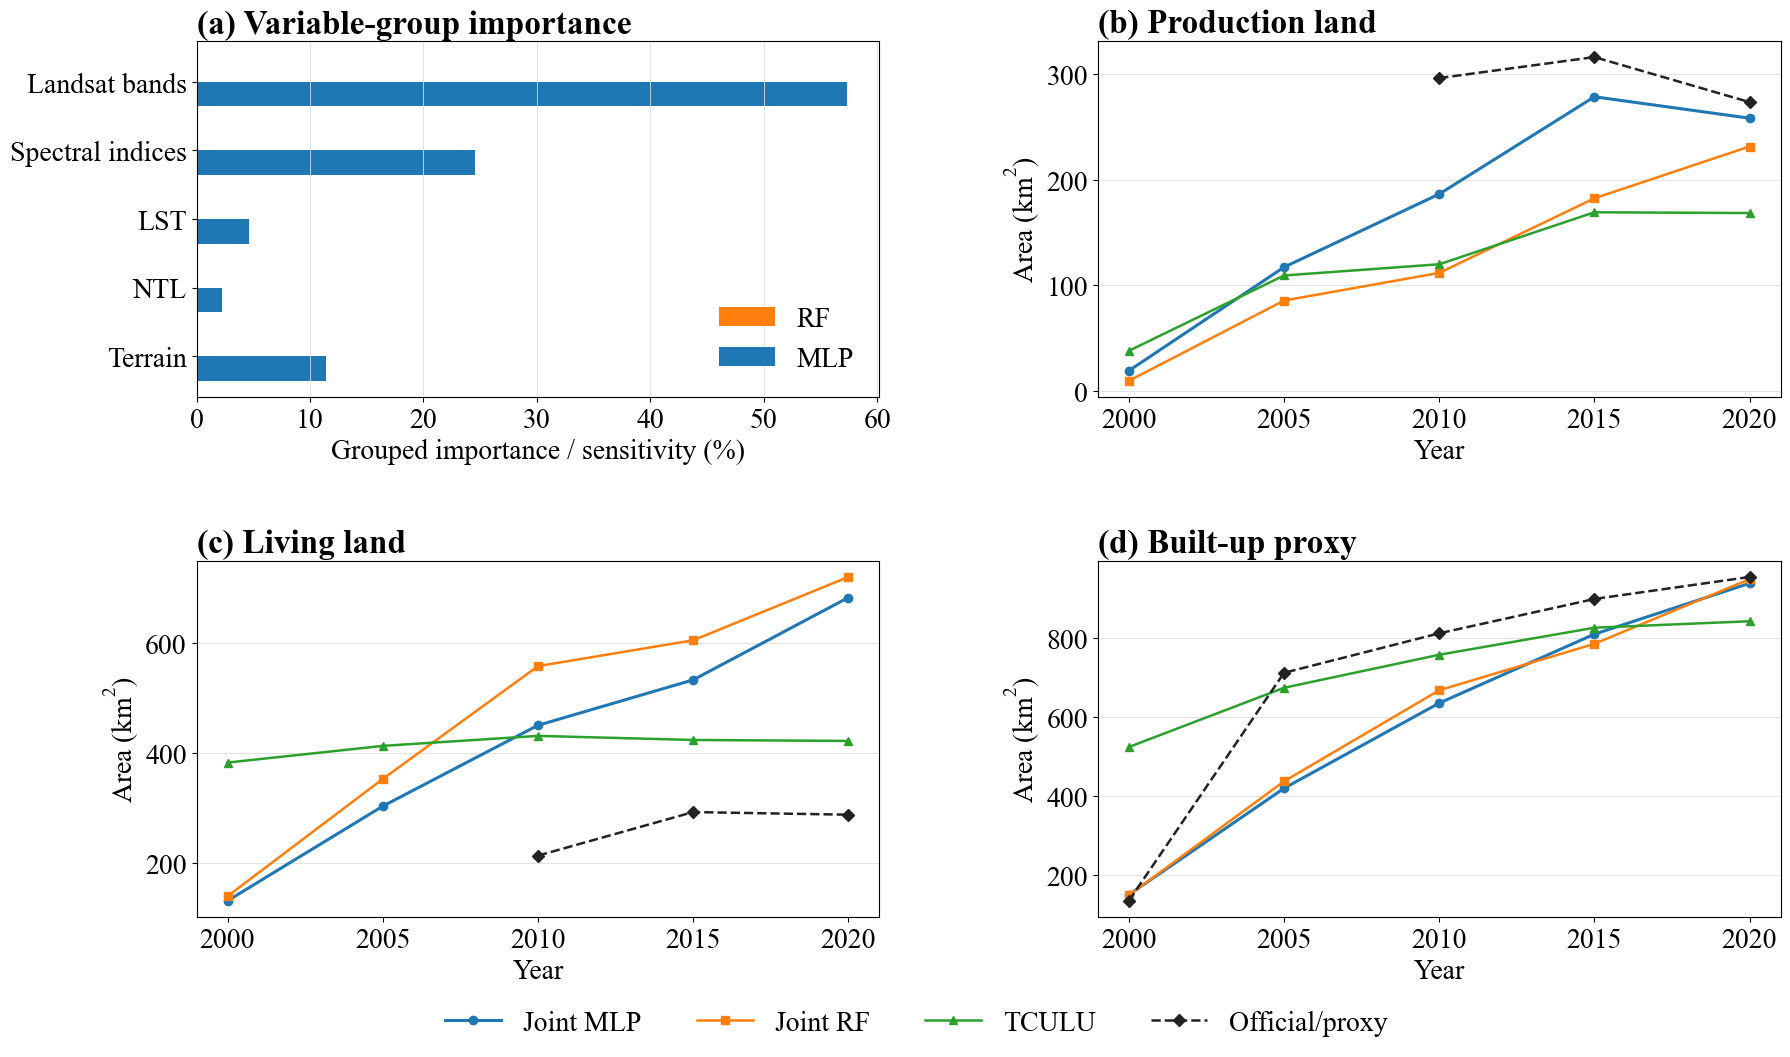

In [17]:
# Create model-validation tables and figures.
%run code/23_plot_model_validation.py


### Part 3.2. Land-Use Change


Reading Shenzhen boundary shapefile...
Reading five-class land-use GPKG...
Start plotting...
Saving figure to: /Volumes/拯救者PSSD/Aexercise/Shenzhen/UFSs_25/shenzhen-functional/figures/Fig3_Shenzhen_LandUse_Frykit_Projected.pdf


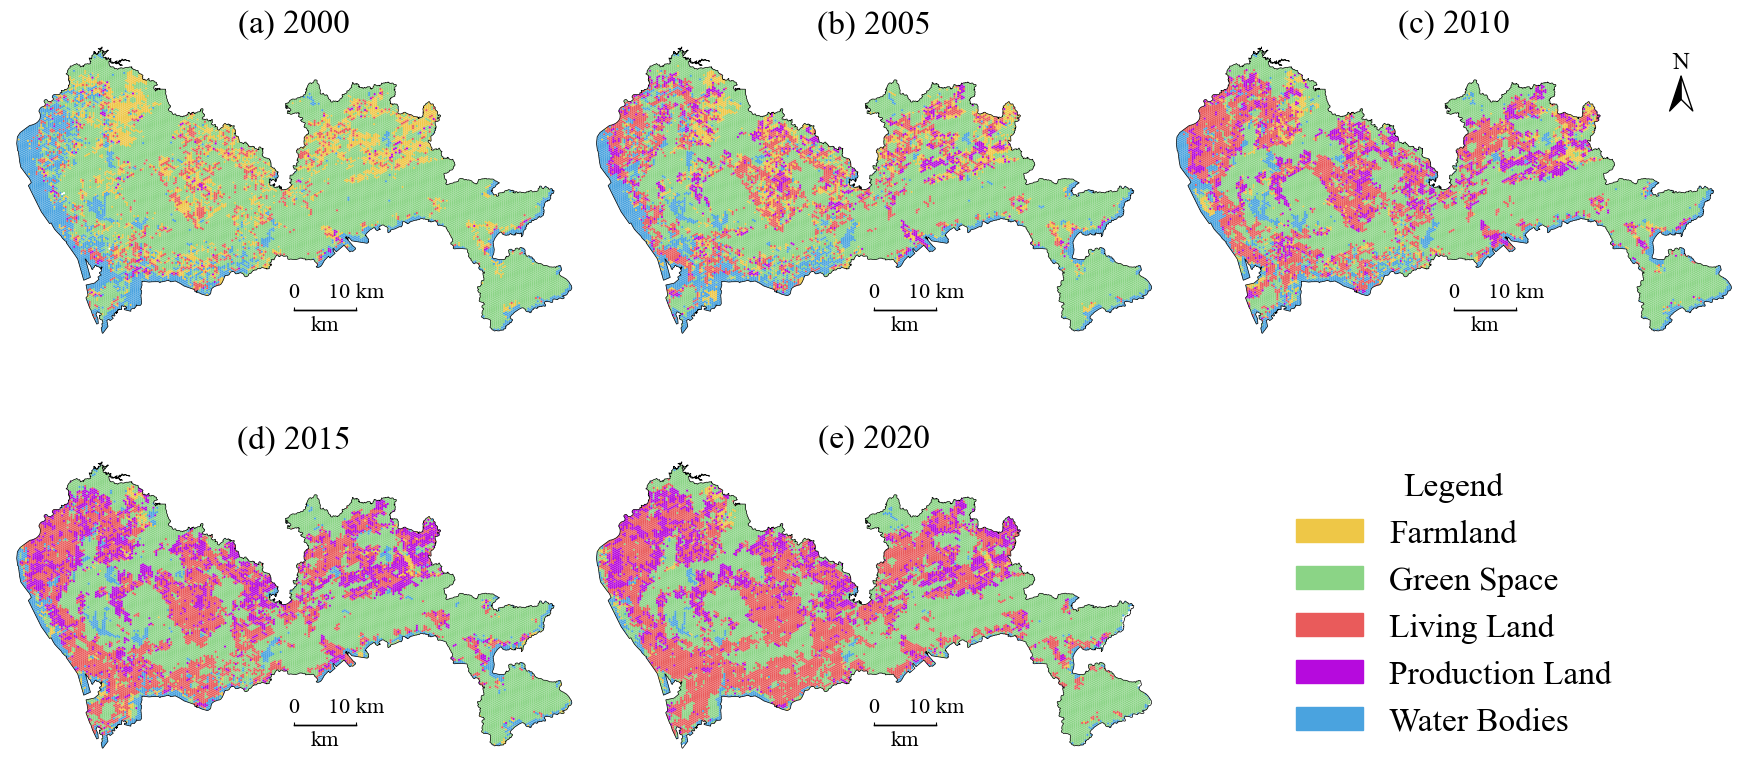

In [18]:
# Create multi-year land-use maps.
%run code/24_plot_landuse_maps.py


In [19]:
# Create land-use area bar charts.
%run code/25_plot_landuse_area_bars.py


Calculating areas...
Area statistics complete; first five rows:
   Year             Type     Area_km2
0  2000         Farmland   319.262943
1  2000      Green Space  1247.060427
2  2000      Living Land   132.314981
3  2000  Production Land    18.927861
4  2000     Water Bodies   247.421712
Chart saved to: /Volumes/拯救者PSSD/Aexercise/Shenzhen/UFSs_25/shenzhen-functional/figures/Fig4_Shenzhen_LandUse_Analysis_Charts_Labeled.pdf


In [20]:
df.to_csv('figures/part32_landuse/landuse_area_2000_2020.csv', index=False, encoding='utf-8-sig')
print(df)

    Year             Type     Area_km2
0   2000         Farmland   319.262943
1   2000      Green Space  1247.060427
2   2000      Living Land   132.314981
3   2000  Production Land    18.927861
4   2000     Water Bodies   247.421712
5   2005         Farmland   196.672389
6   2005      Green Space  1126.809748
7   2005      Living Land   303.616982
8   2005  Production Land   117.041004
9   2005     Water Bodies   221.159569
10  2010         Farmland    97.308616
11  2010      Green Space  1062.650922
12  2010      Living Land   450.084021
13  2010  Production Land   186.307084
14  2010     Water Bodies   168.949049
15  2015         Farmland    39.583099
16  2015      Green Space   987.517732
17  2015      Living Land   532.391842
18  2015  Production Land   278.483178
19  2015     Water Bodies   127.323841
20  2020         Farmland    21.867520
21  2020      Green Space   942.484841
22  2020      Living Land   681.528642
23  2020  Production Land   258.195070
24  2020     Water Bodies

In [22]:
df_percent.to_csv('figures/part32_landuse/landuse_percent_2000_2020.csv', index=False, encoding='utf-8-sig')
print(df_percent)

Type   Farmland  Green Space  Living Land  Production Land  Water Bodies
Year                                                                    
2000  16.247578    63.464025     6.733628         0.963256     12.591513
2005  10.007247    57.335263    15.448890         5.955377     11.253224
2010   4.951337    54.070681    22.901546         9.479831      8.596605
2015   2.014100    50.247692    27.089601        14.170011      6.478597
2020   1.114694    48.043063    34.740849        13.161466      2.939927


In [21]:
# Create Sankey transition visualization.
%run code/26_plot_landuse_sankey.py


Reading land-use data...
Calculating transitions...
HTML saved to: /Volumes/拯救者PSSD/Aexercise/Shenzhen/UFSs_25/shenzhen-functional/figures/Fig5_Shenzhen_LandUse_Sankey.html


In [23]:
# Export land-use transition data for the Sankey figure.
%run code/27_export_landuse_sankey_data.py


Reading land-use GPKG...
Calculating Sankey transition results...

--- Sankey transition data（actual transitions only；area unit：km²） ---
   Period Source Type Target Type Area (km2) Sankey Label
2000-2005    Farmland Green Space    75.7562         75.8
2000-2005    Farmland      Living    87.4277         87.4
2000-2005    Farmland  Production    43.0374         43.0
2000-2005    Farmland       Water    15.0976         15.1
2000-2005 Green Space    Farmland    74.4526         74.5
2000-2005 Green Space      Living    86.0676         86.1
2000-2005 Green Space  Production    36.8508         36.9
2000-2005 Green Space       Water    49.0149         49.0
2000-2005      Living    Farmland     9.9849         10.0
2000-2005      Living Green Space    16.1547         16.2
2000-2005      Living  Production    17.5212         17.5
2000-2005      Living       Water     2.9838          3.0
2000-2005  Production    Farmland     1.1432          1.1
2000-2005  Production Green Space     0.8314       

### Part 3.3. Thermal Environment


Saved outputs to: /Volumes/拯救者PSSD/Aexercise/Shenzhen/UFSs_25/shenzhen-functional/figures/part33_thermal_descriptive


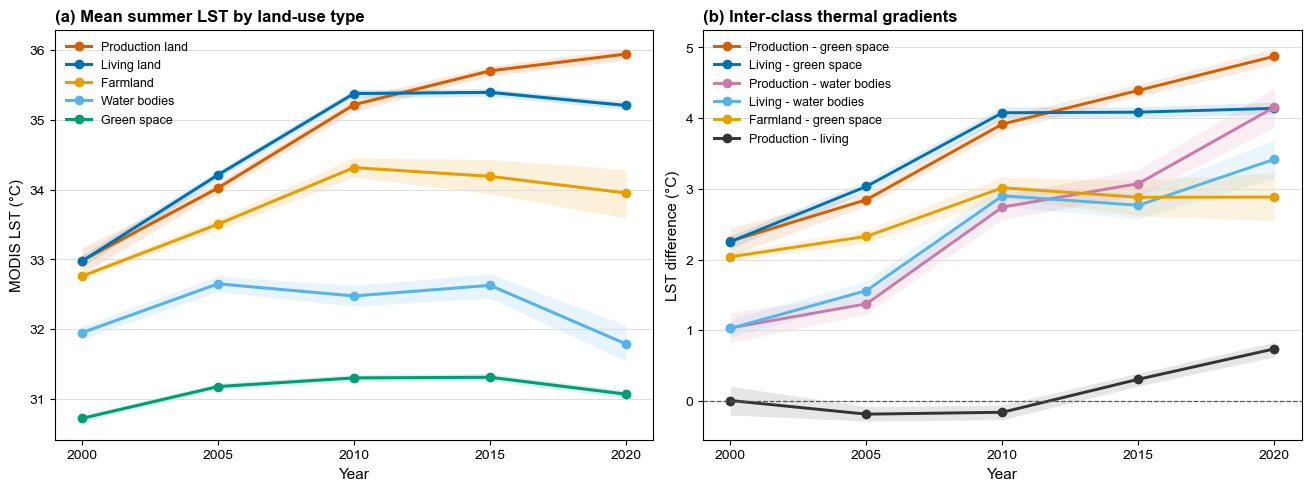

In [24]:
# Create thermal descriptive figures.
%run code/28_plot_thermal_descriptive.py


In [25]:
# Create MODIS LST map figures.
%run code/29_plot_modis_lst_maps.py


Saved outputs to: /Volumes/拯救者PSSD/Aexercise/Shenzhen/UFSs_25/shenzhen-functional/figures/part33_thermal_descriptive
Common color scale: 27.29 to 38.10 °C


Saved outputs to: /Volumes/拯救者PSSD/Aexercise/Shenzhen/UFSs_25/shenzhen-functional/figures/part33_transition_effects

Stage summary:
    stage  background_normalized_mean  background_normalized_n  psm_att_mean  psm_n_matched stage_label           period
2000_2005                       0.835                     2874         0.552         2869.0   2000-2005  Early Expansion
2005_2010                       0.878                     2560         0.361         2513.0   2005-2010  Early Expansion
2010_2015                       0.099                     2138         0.069         2053.0   2010-2015 Later Transition
2015_2020                       0.106                     1700         0.051         1547.0   2015-2020 Later Transition


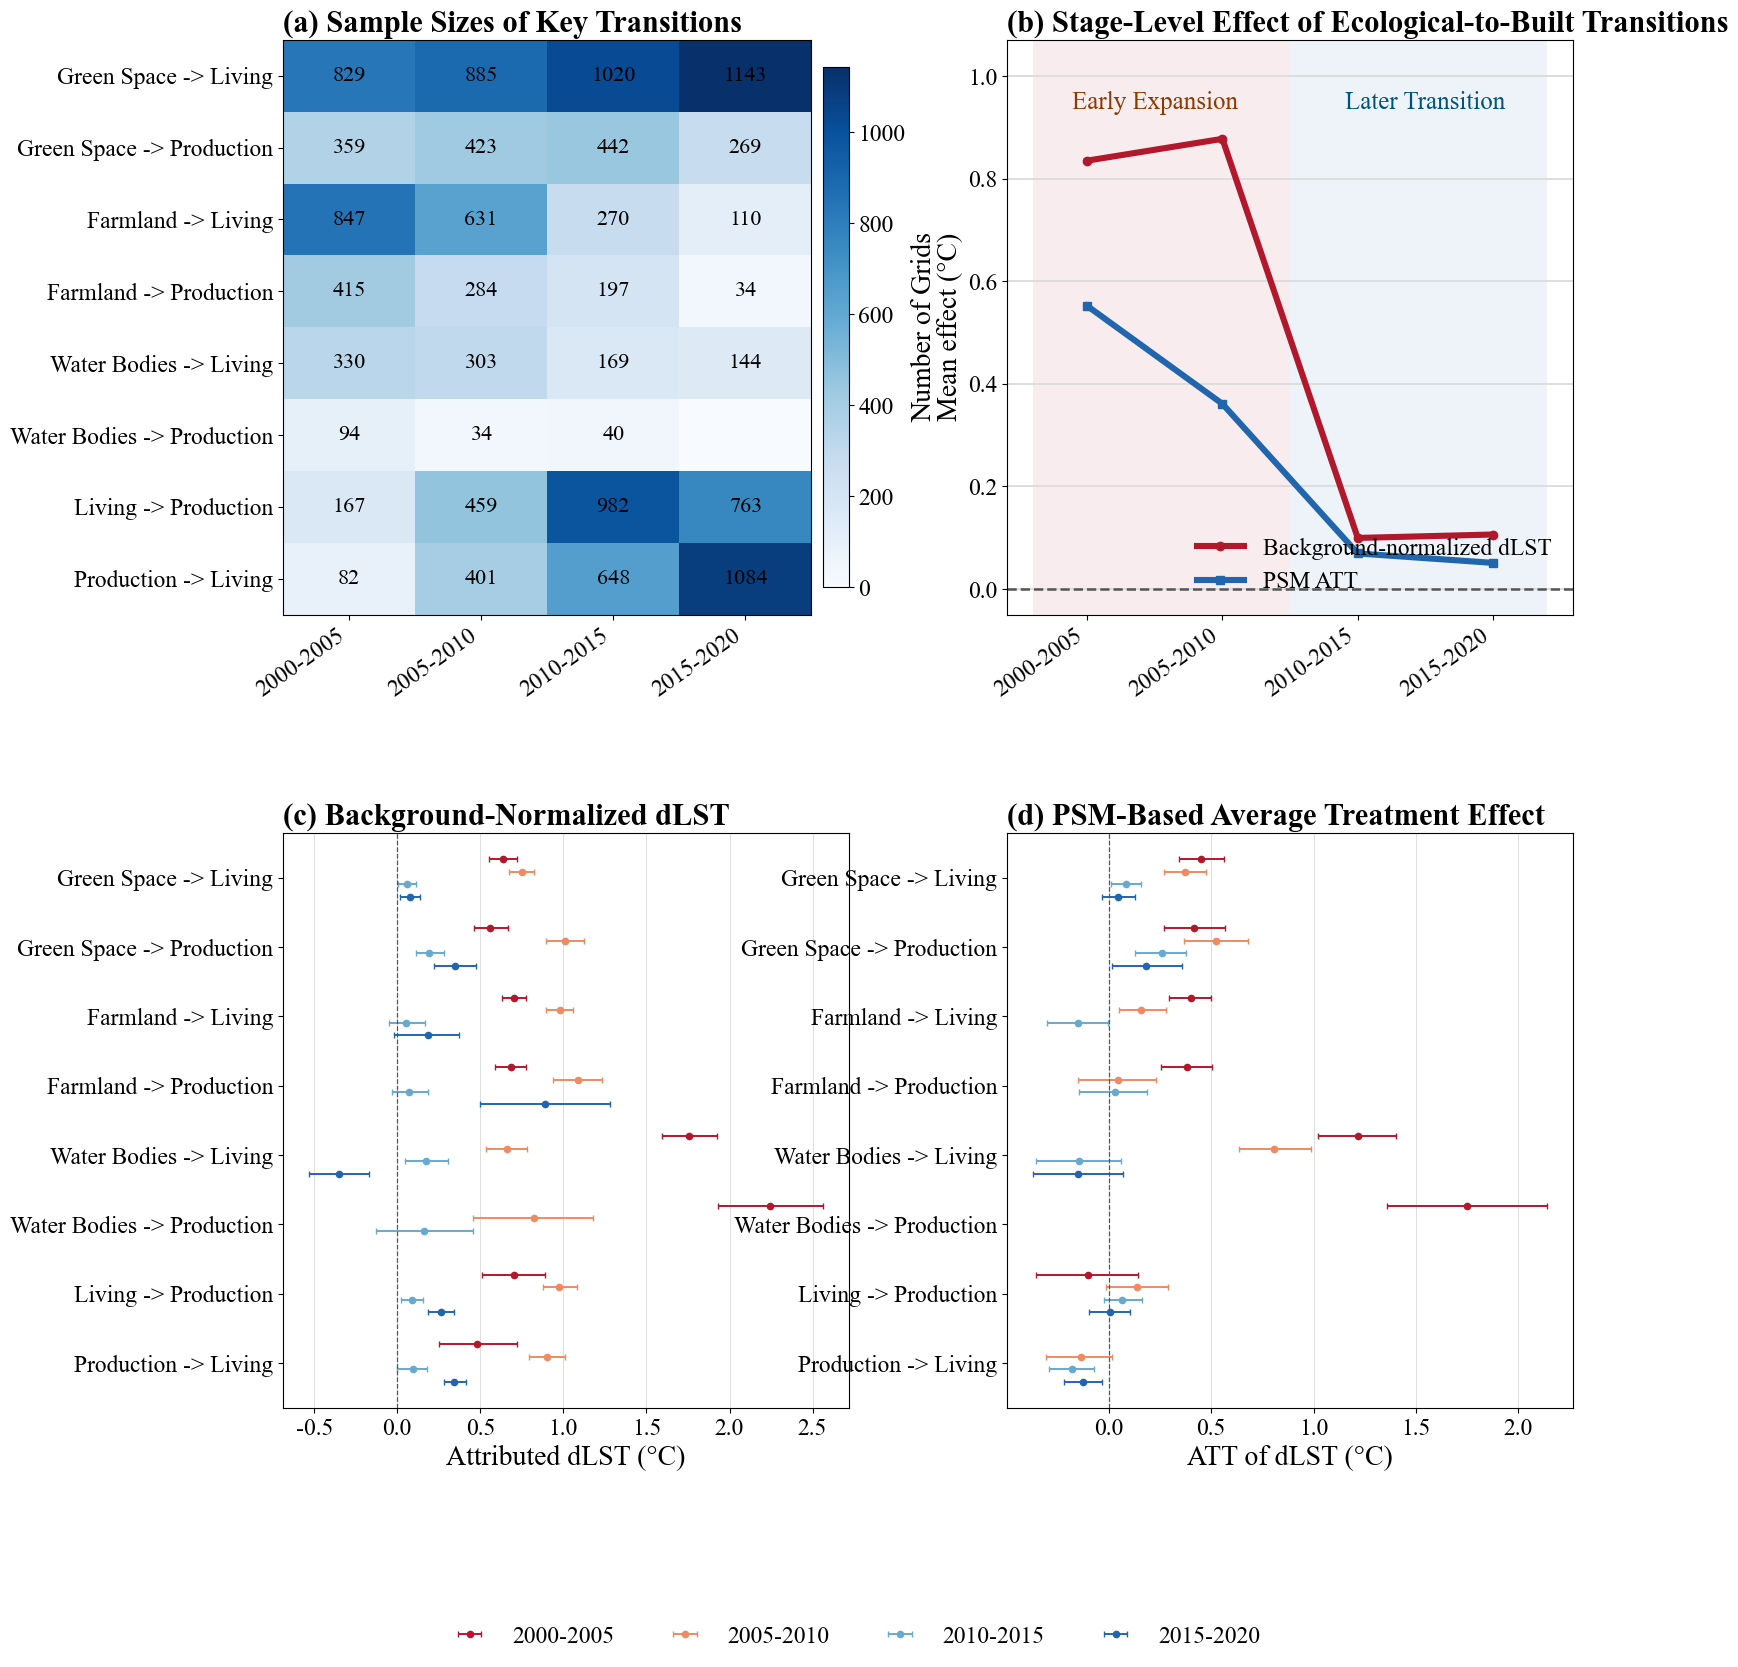

In [26]:
# Create thermal transition-effect figures.
%run code/30_plot_thermal_transition_effects.py
